In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40909")
client

<Client: 'tcp://127.0.0.1:40909' processes=9 threads=72, memory=136.41 GiB>

In [2]:
import xarray as xr
import numpy as np
import os.path as op
import tripyview as tpv
import gsw
import matplotlib.pyplot as plt

# xr.set_options(keep_attrs=True)
# do_parallel       = True
# parallel_nprc     = 16   # number of dask workers
# parallel_nprc_bin = 8   # number of processor used to parallize the binning loop
# parallel_tmem     = 256   # max. available RAM

%matplotlib inline

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
ddir = '/work/uo0119/a270067/runtime/awicm3-v3.1/'
sdir = '/scratch/b/b383315/'
wdir = '/work/ba1254/b383315/fesom2/next/'

In [5]:
nz = 47

plt_contb = True        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tcf'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, -30] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
# proj = 'rob'               # Robinson projection
proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 2                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 2                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cmin      = None
cmax      = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

In [6]:
mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
                            do_info=True, do_pickle=False
                           )
mesh

 > load mesh from *.out files: /work/ab0995/a270067/fesom2/next/mesh
 > load e_area from fesom.mesh.diag.nc
 > load n_area from fesom.mesh.diag.nc
 > compute lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_pbnd.shp
 > augment lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_focus=0.shp
___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________


___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________

In [7]:
NXX = 44
yy = 2014
try:
    dsg = xr.open_dataset(op.join(ddir,'N%2d/outdata/fesom/temp.fesom.%4d.nc'
                              % (NXX,yy))
               )
except:
    dsg = xr.open_dataset(op.join(ddir,'N%2d/outdata/fesom/yearly/temp.fesom.%4d.nc'
                              % (NXX,yy))
               )

nd = 29
dsg.isel(nz1=slice(nd,None))

<xarray.Dataset> Size: 11GB
Dimensions:  (time: 12, nz1: 18, x: 12952215)
Coordinates:
  * time     (time) datetime64[ns] 96B 2014-01-31T23:57:00 ... 2014-12-31T23:...
  * nz1      (nz1) float64 144B 1.81e+03 2.035e+03 ... 5.825e+03 6.125e+03
Dimensions without coordinates: x
Data variables:
    temp     (time, nz1, x) float32 11GB ...
Attributes: (12/21)
    CDI:                                 Climate Data Interface version 2.2.4...
    Conventions:                         CF-1.6
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       e23bc823
    FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
    ...                                  ...
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      7
    FESOM_use_wsplit:                    -1
    FESOM_autorotate_back_to_geo:        0
    history:                             Thu Mar 13 01:48:27 2025: cdo cat te...
    CDO:                                 Climate Data Operators version 2.2.2...

In [12]:
latN = -29.
latS = -78.1
dl = .1
NXX = 43
ys = 2066
ye = 2100

pt_path = op.join(wdir,'climatology/N%2d.%4s.fesom.%4d-%4d.nc'
                  % (NXX,'temp',ys,ye))
ps_path = op.join(wdir,'climatology/N%2d.%4s.fesom.%4d-%4d.nc'
                  % (NXX,'salt',ys,ye))

depths = dsg.nz1.values[nd:]

for dd in depths:
    
    pt = tpv.load_data_fesom2(mesh, pt_path, do_filename=True,
                              vname="temp", do_info=False,
                              depth=[dd], 
                             ).temp
    ps = tpv.load_data_fesom2(mesh, ps_path, do_filename=True,
                              vname="salt", do_info=False,
                              depth=[dd], 
                             ).salt
        
    for ll in np.arange(latS-.5*dl, latN+.5*dl, dl):

        pt_temp = pt.where(pt.lat<ll+dl,drop=True
                          )
        pt_temp = pt_temp.where(pt_temp.lat>=ll,drop=True
                               ).mean('nod2',skipna=True
                                            ).compute()
        ps_temp = ps.where(ps.lat<ll+dl,drop=True
                          )
        ps_temp = ps_temp.where(ps_temp.lat>=ll,drop=True
                               ).mean('nod2',skipna=True
                                            ).compute()
            
        if ll == latS-.5*dl:
            PT = pt_temp
            PS = ps_temp
        else:
            PT = xr.concat([PT, pt_temp], 'lat')
            PS = xr.concat([PS, ps_temp], 'lat')

        del pt_temp, ps_temp

    dsave = xr.DataArray(PT.chunk({'lat':100}).data, 
                         dims=['lat']
                        ).to_dataset(name='theta')
    dsave['salt'] = xr.DataArray(PS.chunk({'lat':100}).data, 
                                 dims=['lat']
                                )
    dsave.coords['lat'] = ('lat', np.arange(latS,latN+dl,dl))
    fig, ax = plt.subplots()
    ax2 = ax.twinx()
    ax.plot(dsave.lat, dsave.theta, c='r')
    ax2.plot(dsave.lat, dsave.salt, c='b')
    plt.show()
        
    if dd == dsg.nz1.values[nd]:
        print(dsave)
            
    dsave.to_zarr(op.join(wdir,
                          'SouthernOcean/N%2d/zonal-mean/TandS_%04dm_%4d-%4d.zarr'
                          % (NXX,int(dd),ys,ye)),
                  mode='w'
                 )
    dsave.close()
    del PT, PS

KeyboardInterrupt: 

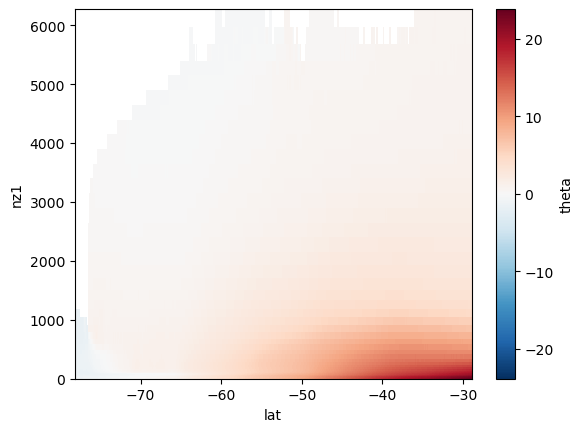

<xarray.Dataset> Size: 374kB
Dimensions:  (nz1: 47, lat: 492)
Coordinates:
  * lat      (lat) float64 4kB -78.1 -78.0 -77.9 -77.8 ... -29.2 -29.1 -29.0
  * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
Data variables:
    theta    (nz1, lat) float64 185kB -0.9675 -0.9857 -1.022 ... 0.7335 0.7335
    salt     (nz1, lat) float64 185kB 34.25 34.27 34.28 ... 34.74 34.74 34.74


In [8]:
NXX = 43
ys = 2066
ye = 2100

depths = dsg.nz1.values

for dd in depths:
    
    if dd == depths[0]:
        ds = xr.open_dataset(op.join(wdir,
                              'SouthernOcean/N%2d/zonal-mean/TandS_%04dm_%4d-%4d.zarr'
                              % (NXX,int(dd),ys,ye))
                            )
    else:
        ds = xr.concat([ds, xr.open_dataset(op.join(wdir,
                              'SouthernOcean/N%2d/zonal-mean/TandS_%04dm_%4d-%4d.zarr'
                              % (NXX,int(dd),ys,ye)))
                       ], 'nz1')
        
ds.coords['nz1'] = ('nz1', depths)

ds.theta.plot(rasterized=True)
plt.show()
print(ds)

ds.to_zarr(op.join(wdir, 'SouthernOcean/N%2d/zonal-mean/TandS_%4d-%4d.zarr'
                     % (NXX,ys,ye))
            )

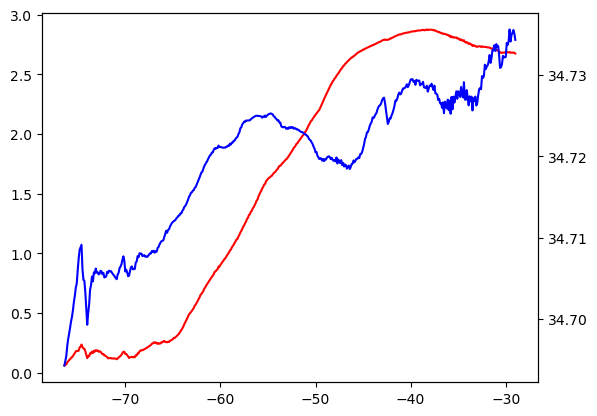

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<xarray.Dataset> Size: 12kB
Dimensions:  (lat: 492)
Coordinates:
  * lat      (lat) float64 4kB -78.1 -78.0 -77.9 -77.8 ... -29.2 -29.1 -29.0
Data variables:
    theta    (lat) float64 4kB dask.array<chunksize=(100,), meta=np.ndarray>
    salt     (lat) float64 4kB dask.array<chunksize=(100,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


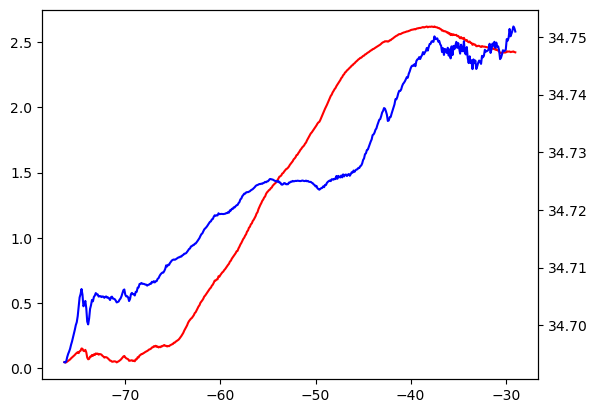

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


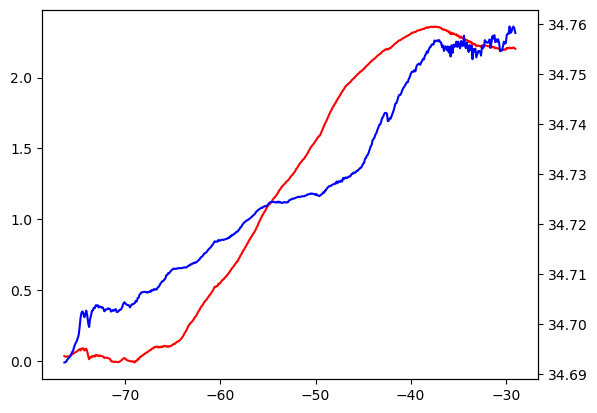

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


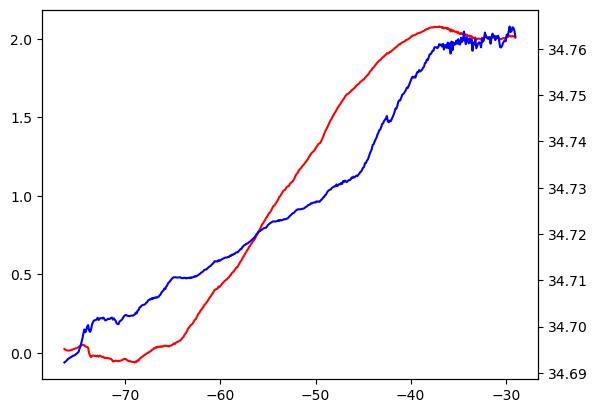

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


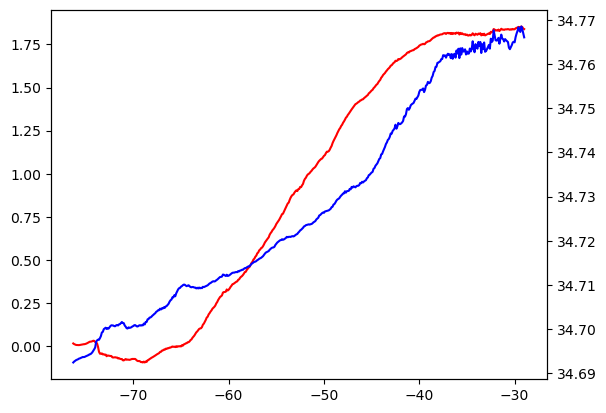

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/

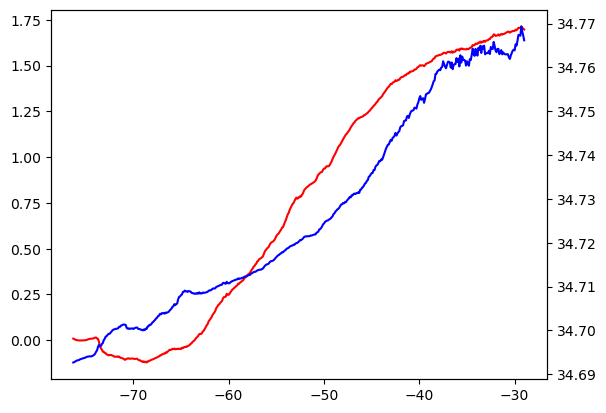

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/

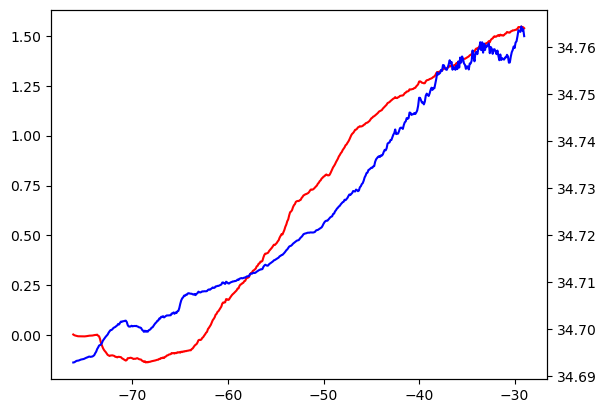

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


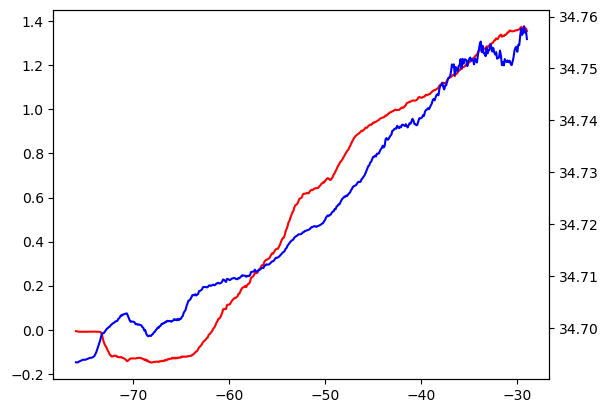

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


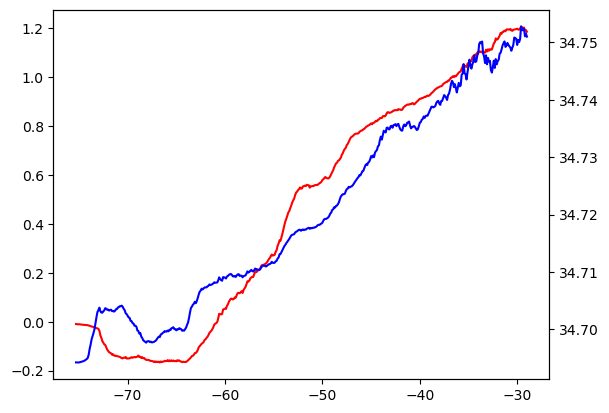

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/

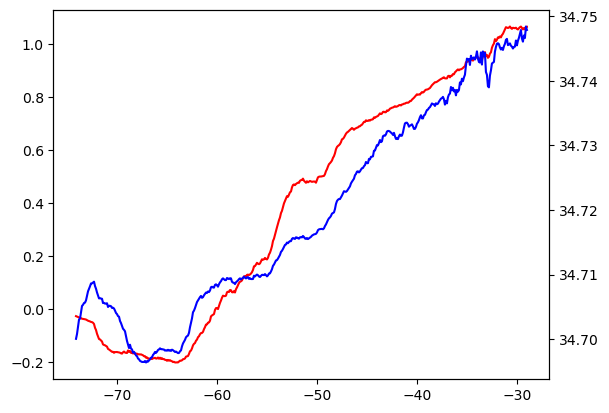

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


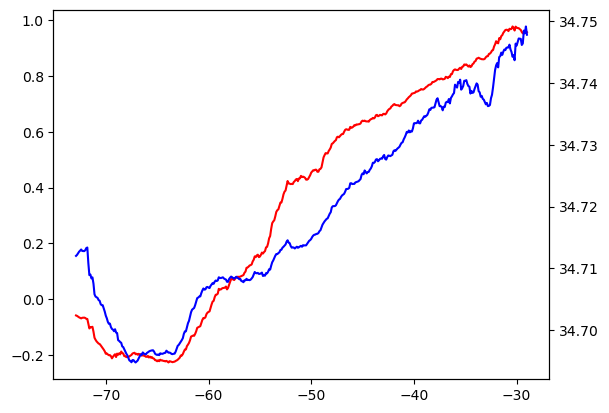

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/

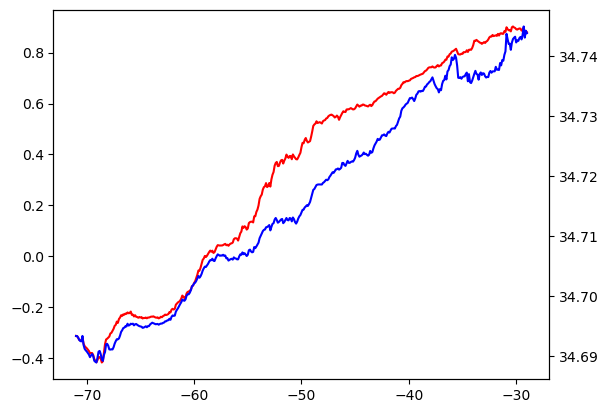

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/

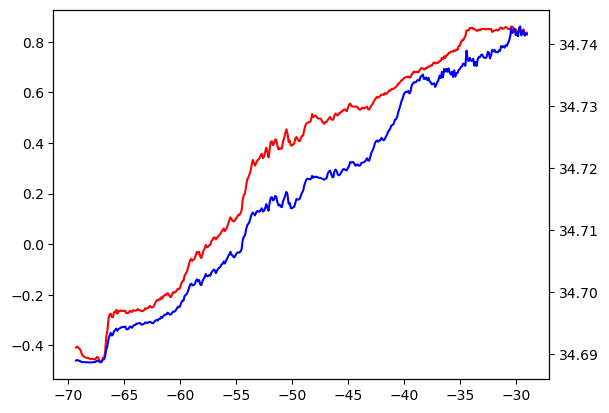

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


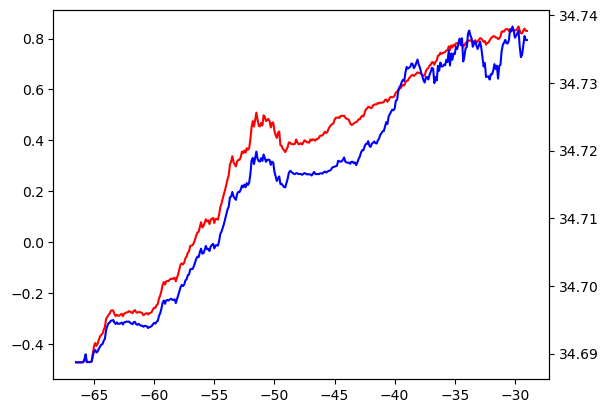

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


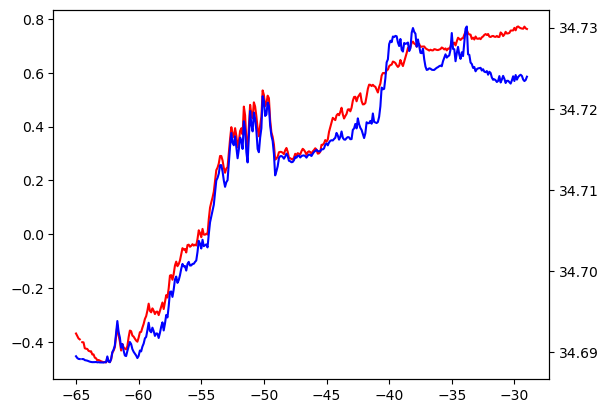

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


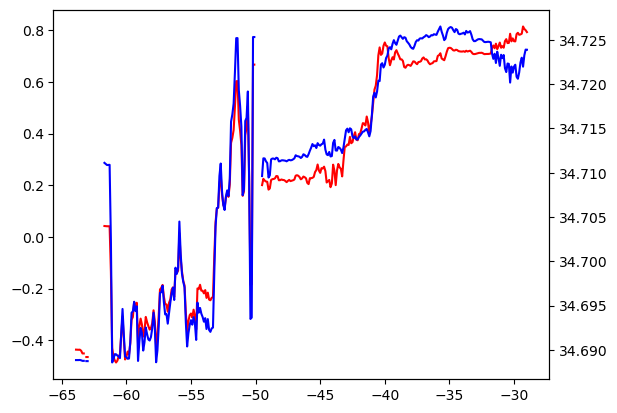

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


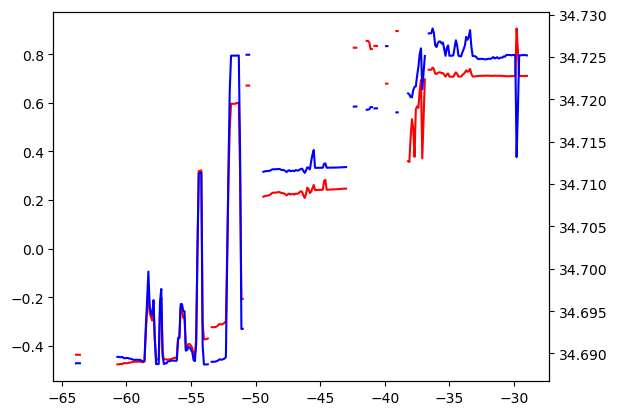

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


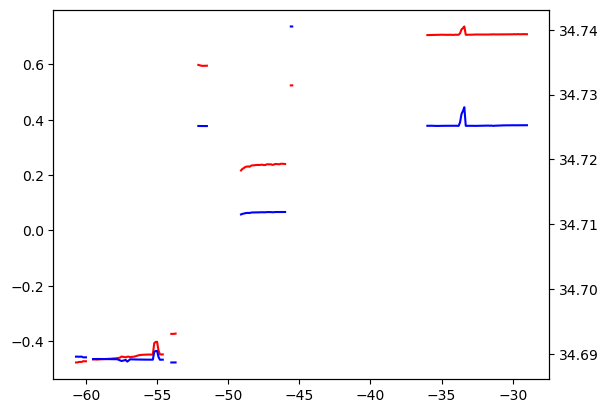

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [19]:
latN = -29.
latS = -78.1
dl = .1
ys = 1980
ye = 2014
NXX = 44

pt_path = op.join(wdir,'climatology/N%2d.%4s.fesom.%4d-%4d.nc'
                  % (NXX,'temp',ys,ye))
ps_path = op.join(wdir,'climatology/N%2d.%4s.fesom.%4d-%4d.nc'
                  % (NXX,'salt',ys,ye))

depths = dsg.nz1.values[nd:]

for dd in depths:
    
    pt = tpv.load_data_fesom2(mesh, pt_path, do_filename=True,
                              vname="temp", do_info=False,
                              depth=[dd], 
                             ).temp
    ps = tpv.load_data_fesom2(mesh, ps_path, do_filename=True,
                              vname="salt", do_info=False,
                              depth=[dd], 
                             ).salt
        
    for ll in np.arange(latS-.5*dl, latN+.5*dl, dl):

        pt_temp = pt.where(pt.lat<ll+dl,drop=True
                          )
        pt_temp = pt_temp.where(pt_temp.lat>=ll,drop=True
                               ).mean('nod2',skipna=True
                                            ).compute()
        ps_temp = ps.where(ps.lat<ll+dl,drop=True
                          )
        ps_temp = ps_temp.where(ps_temp.lat>=ll,drop=True
                               ).mean('nod2',skipna=True
                                            ).compute()
            
        if ll == latS-.5*dl:
            PT = pt_temp
            PS = ps_temp
        else:
            PT = xr.concat([PT, pt_temp], 'lat')
            PS = xr.concat([PS, ps_temp], 'lat')

        del pt_temp, ps_temp

    dsave = xr.DataArray(PT.chunk({'lat':100}).data, 
                         dims=['lat']
                        ).to_dataset(name='theta')
    dsave['salt'] = xr.DataArray(PS.chunk({'lat':100}).data, 
                                 dims=['lat']
                                )
    dsave.coords['lat'] = ('lat', np.arange(latS,latN+dl,dl))
    fig, ax = plt.subplots()
    ax2 = ax.twinx()
    ax.plot(dsave.lat, dsave.theta, c='r')
    ax2.plot(dsave.lat, dsave.salt, c='b')
    plt.show()
        
    if dd == dsg.nz1.values[nd]:
        print(dsave)
            
    dsave.to_zarr(op.join(wdir,
                          'SouthernOcean/N%2d/zonal-mean/TandS_%04dm_%4d-%4d.zarr'
                          % (NXX,int(dd),ys,ye)),
                  mode='w'
                 )
    dsave.close()
    del PT, PS

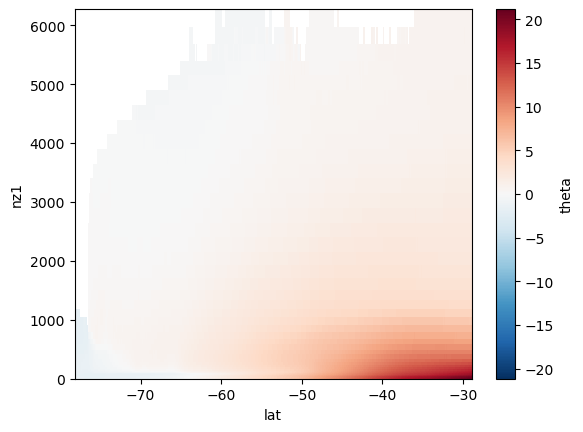

<xarray.Dataset> Size: 374kB
Dimensions:  (nz1: 47, lat: 492)
Coordinates:
  * lat      (lat) float64 4kB -78.1 -78.0 -77.9 -77.8 ... -29.2 -29.1 -29.0
  * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
Data variables:
    theta    (nz1, lat) float64 185kB -1.602 -1.622 -1.619 ... 0.7094 0.7092
    salt     (nz1, lat) float64 185kB 34.5 34.5 34.52 ... 34.73 34.73 34.73


In [9]:
NXX = 44
ys = 1980
ye = 2014

depths = dsg.nz1.values

for dd in depths:
    
    if dd == depths[0]:
        ds = xr.open_dataset(op.join(wdir,
                              'SouthernOcean/N%2d/zonal-mean/TandS_%04dm_%4d-%4d.zarr'
                              % (NXX,int(dd),ys,ye))
                            )
    else:
        ds = xr.concat([ds, xr.open_dataset(op.join(wdir,
                              'SouthernOcean/N%2d/zonal-mean/TandS_%04dm_%4d-%4d.zarr'
                              % (NXX,int(dd),ys,ye)))
                       ], 'nz1')
        
ds.coords['nz1'] = ('nz1', depths)

ds.theta.plot(rasterized=True)
plt.show()
print(ds)

ds.to_zarr(op.join(wdir, 'SouthernOcean/N%2d/zonal-mean/TandS_%4d-%4d.zarr'
                     % (NXX,ys,ye))
            )

In [8]:
# mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
# mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
#                             do_info=True, do_pickle=False
#                            )

diag = xr.open_dataset(op.join(mesh_path, 'fesom.mesh.diag.nc'),
                       chunks={'nz':1,"nz1":1,'elem':100000,
                               'nod2':100000,'edg_n':100000}
                      )

diag

<xarray.Dataset> Size: 10GB
Dimensions:            (nz: 48, nz1: 47, elem: 25742475, nod2: 12952215, n3: 3,
                        n2: 2, N: 8, edg_n: 38695599, n4: 4)
Coordinates:
  * nz                 (nz) float64 384B 0.0 -5.0 -10.0 ... -6e+03 -6.25e+03
  * nz1                (nz1) float64 376B -2.5 -7.5 ... -5.825e+03 -6.125e+03
Dimensions without coordinates: elem, nod2, n3, n2, N, edg_n, n4
Data variables: (12/19)
    elem_area          (elem) float64 206MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nlevels_nod2D      (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nlevels            (elem) int32 103MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nod_in_elem2D_num  (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nod_part           (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    elem_part          (elem) int32 103MB dask.array<chunksize=(100000,), meta=np.ndarray>
    ...                 ...
    nod_in_elem2D      (N, nod2) int32 414MB dask.array<chunksize=(8, 100000), meta=np.ndarray>
    edges              (n2, edg_n) int32 310MB dask.array<chunksize=(2, 100000), meta=np.ndarray>
    edge_tri           (n2, edg_n) int32 310MB dask.array<chunksize=(2, 100000), meta=np.ndarray>
    edge_cross_dxdy    (n4, edg_n) float64 1GB dask.array<chunksize=(4, 100000), meta=np.ndarray>
    gradient_sca_x     (elem, n3) float64 618MB dask.array<chunksize=(100000, 3), meta=np.ndarray>
    gradient_sca_y     (elem, n3) float64 618MB dask.array<chunksize=(100000, 3), meta=np.ndarray>

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a fu

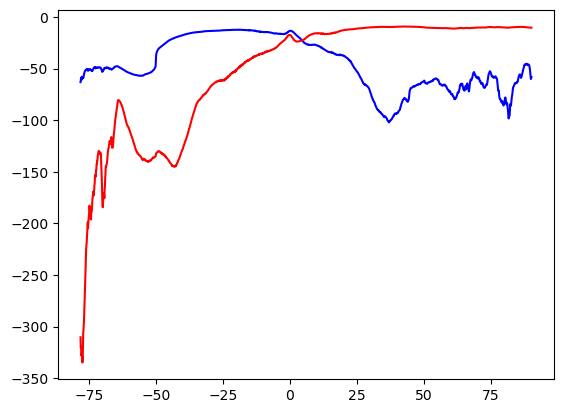

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
latN = 90
latS = -78.1
dl = .1
NXX = 50
ys = 2090
ye = 2101

ystart = ys
months = range(12)

area = diag.nod_area.isel(nz=0).reset_coords(drop=True).load()
area.coords["lat"] = ("nod2", diag.lat.data)
area.coords["lon"] = ("nod2", diag.lon.data)

for yy in range(ystart,ye):
    
    h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
                     % (NXX,yy)
                    )
    
    mldw = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                   vname="MLD3", do_info=False,
                                   year=yy, mon=1
                                  ).chunk({'nod2':100000}).MLD3
    mldw = xr.concat([mldw, tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                   vname="MLD3", do_info=False,
                                   year=yy, mon=2
                                  ).chunk({'nod2':100000}).MLD3
                     ], "time")
    mldw = xr.concat([mldw, tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                   vname="MLD3", do_info=False,
                                   year=yy, mon=3
                                  ).chunk({'nod2':100000}).MLD3
                     ], "time")
    mlds = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                   vname="MLD3", do_info=False,
                                   year=yy, mon=7
                                  ).chunk({'nod2':100000}).MLD3
    mlds = xr.concat([mlds, tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                   vname="MLD3", do_info=False,
                                   year=yy, mon=8
                                  ).chunk({'nod2':100000}).MLD3
                     ], "time")
    mlds = xr.concat([mlds, tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                   vname="MLD3", do_info=False,
                                   year=yy, mon=9
                                  ).chunk({'nod2':100000}).MLD3
                     ], "time")
    if yy == ystart:
        mldW = mldw.where(mldw<0.)
        mldS = mlds.where(mlds<0.)
    else:
        mldW = xr.concat([mldW, mldw.where(mldw<0.)], "time")
        mldS = xr.concat([mldS, mlds.where(mlds<0.)], "time")
        
mldJFM = mldW.mean("time",skipna=True).load()
maskw = xr.DataArray(mldJFM.to_masked_array().mask, 
                     dims=mldJFM.dims, coords=mldJFM.coords
                    )
    
mldJAS = mldS.mean("time",skipna=True).load()
masks = xr.DataArray(mldJAS.to_masked_array().mask, 
                     dims=mldJAS.dims, coords=mldJAS.coords
                    )
    # for mm in range(1,13):
    #     mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
    #                                vname="MLD3", do_info=False,
    #                                year=yy, mon=mm
    #                               ).chunk({'nod2':100000}).MLD3
    #     mld = mld.where(mld<0.).load()
    #     maskh = xr.DataArray(mld.to_masked_array().mask, 
    #                          dims=mld.dims, coords=mld.coords
    #                         )
del mldW, mldS
        
for ll in np.arange(latS-.5*dl, latN, dl):

    h_temp = ((mldJFM * area
              ).where((mldJFM.lat<ll+dl) & (mldJFM.lat>=ll),
                      drop=True
                     ).sum('nod2',skipna=True)
              / area.where(~maskw).where((area.lat.load()<ll+dl) 
                                         & (area.lat.load()>=ll),
                                         drop=True
                                        ).sum('nod2',skipna=True)
             ).reset_coords(drop=True).compute()

    if ll == latS-.5*dl:
        hw = h_temp
    else:
        hw = xr.concat([hw, h_temp], 'lat')
    del h_temp

    h_temp = ((mldJAS * area
              ).where((mldJAS.lat<ll+dl) & (mldJAS.lat>=ll),
                      drop=True
                     ).sum('nod2',skipna=True)
              / area.where(~masks).where((area.lat.load()<ll+dl) 
                                         & (area.lat.load()>=ll),
                                         drop=True
                                        ).sum('nod2',skipna=True)
             ).reset_coords(drop=True).compute()

    if ll == latS-.5*dl:
        hs = h_temp
    else:
        hs = xr.concat([hs, h_temp], 'lat')
    del h_temp

    # if mm == 1:
    #     HX = hx
    # else:
    #     HX = xr.concat([HX, hx], "time")
    # del hx, mld, maskh

dsave = xr.DataArray(hw.chunk({"lat":100}).data, 
                     dims=["lat"]
                    ).to_dataset(name="JFM")
dsave["JAS"] = xr.DataArray(hs.chunk({"lat":100}).data, 
                     dims=["lat"]
                    )
dsave.coords["lat"] = ("lat", np.arange(latS,latN+dl,dl))

fig, ax = plt.subplots()
ax.plot(dsave.lat, dsave.JFM, c='b')
ax.plot(dsave.lat, dsave.JAS, c='r')
plt.show()

dsave.to_zarr(op.join(wdir,
                      'glob-ave/N%2d/MLD_zonal-mean.zarr'
                      % (NXX)),
              mode='w'
             )
dsave.close()
del mldJFM, mldJAS, area

In [15]:
H48 = xr.open_zarr(op.join(wdir,
                      'glob-ave/N%2d/MLD_zonal-mean.zarr'
                      % (48)))
H50 = xr.open_zarr(op.join(wdir,
                      'glob-ave/N%2d/MLD_zonal-mean.zarr'
                      % (50)))

H48win = xr.concat([H48.JAS.sel(lat=slice(None,0.)),
                    H48.JFM.sel(lat=slice(0.,None))], "lat")
H48sum = xr.concat([H48.JFM.sel(lat=slice(None,0.)),
                    H48.JAS.sel(lat=slice(0.,None))], "lat")
H50win = xr.concat([H50.JAS.sel(lat=slice(None,0.)),
                    H50.JFM.sel(lat=slice(0.,None))], "lat")
H50sum = xr.concat([H50.JFM.sel(lat=slice(None,0.)),
                    H50.JAS.sel(lat=slice(0.,None))], "lat")

for mm in range(1,10):
    if mm < 4:
        if mm == 1:
            argoJFM = xr.open_dataset(op.join(wdir,"../../Hosoda/ml_MLD_CLIM_%02d.nc" 
                                            % mm)
                                     ).mean("LONGITUDE",skipna=True)
        else:
            argoJFM = xr.concat([argoJFM,
                               xr.open_dataset(op.join(wdir,"../../Hosoda/ml_MLD_CLIM_%02d.nc" 
                                                       % mm)
                                              ).mean("LONGITUDE",skipna=True)
                              ], "time")
    elif mm > 6:
        if mm == 7:
            argoJAS = xr.open_dataset(op.join(wdir,"../../Hosoda/ml_MLD_CLIM_%02d.nc" 
                                            % mm)
                                     ).mean("LONGITUDE",skipna=True)
        else:
            argoJAS = xr.concat([argoJAS,
                               xr.open_dataset(op.join(wdir,"../../Hosoda/ml_MLD_CLIM_%02d.nc" 
                                                       % mm)
                                              ).mean("LONGITUDE",skipna=True)
                              ], "time")
argoJFM = argoJFM.mean("time",skipna=True)
argoJAS = argoJAS.mean("time",skipna=True)
            
H48win, H50sum, argoJFM, argoJAS

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(<xarray.DataArray 'JAS' (lat: 1682)> Size: 13kB
 dask.array<concatenate, shape=(1682,), dtype=float64, chunksize=(100,), chunktype=numpy.ndarray>
 Coordinates:
   * lat      (lat) float64 13kB -78.1 -78.0 -77.9 -77.8 ... 89.7 89.8 89.9 90.0,
 <xarray.DataArray 'JFM' (lat: 1682)> Size: 13kB
 dask.array<concatenate, shape=(1682,), dtype=float64, chunksize=(100,), chunktype=numpy.ndarray>
 Coordinates:
   * lat      (lat) float64 13kB -78.1 -78.0 -77.9 -77.8 ... 89.7 89.8 89.9 90.0,
 <xarray.Dataset> Size: 4kB
 Dimensions:   (LATITUDE: 180)
 Coordinates:
   * LATITUDE  (LATITUDE) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
 Data variables:
     MLD       (LATITUDE) float32 720B nan nan nan nan nan ... 23.06 nan nan nan
     MLD_TEMP  (LATITUDE) float32 720B nan nan nan nan nan ... -1.64 nan nan nan
     MLD_PSAL  (LATITUDE) float32 720B nan nan nan nan nan ... 30.05 nan nan nan
     MLD_PDEN  (LATITUDE) float32 720B nan nan nan nan nan ... 24.15 nan nan nan
     OBS_NUM   (LA

In [24]:
argowin = xr.concat([argoJAS.MLD.sel(LATITUDE=slice(None,0.)),
                    argoJFM.MLD.sel(LATITUDE=slice(0.,None))], "LATITUDE")
argosum = xr.concat([argoJFM.MLD.sel(LATITUDE=slice(None,0.)),
                    argoJAS.MLD.sel(LATITUDE=slice(0.,None))], "LATITUDE")

/tmp/ipykernel_1238177/2586907711.py:2: PendingDeprecationWarning: The set_tight_layout function will be deprecated in a future version. Use set_layout_engine instead.
  fig.set_tight_layout(True)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


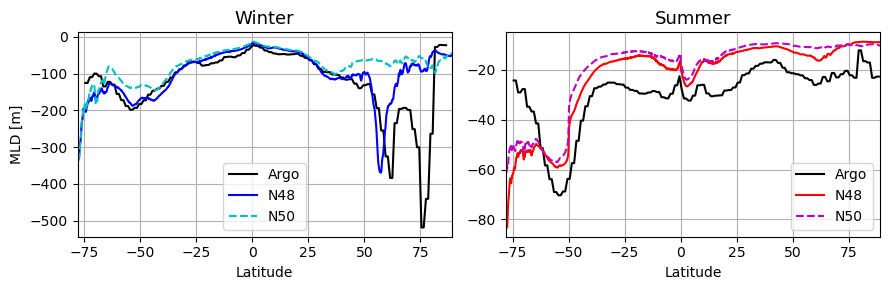

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
fig, axes = plt.subplots(figsize=(9,3), nrows=1, ncols=2)
fig.set_tight_layout(True)

axes[0].plot(argowin.LATITUDE, -argowin, "k", label="Argo")
axes[0].plot(H48win.lat, H48win, "b", label="N48")
axes[0].plot(H50win.lat, H50win, "c--", label="N50")

axes[1].plot(argosum.LATITUDE, -argosum, "k", label="Argo")
axes[1].plot(H48sum.lat, H48sum, "r", label="N48")
axes[1].plot(H50sum.lat, H50sum, "m--", label="N50")

axes[1].set_title(r"Summer", fontsize=13)
axes[0].set_title(r"Winter", fontsize=13)

axes[0].set_ylabel(r"MLD [m]")
axes[0].set_xlabel(r"Latitude")
axes[1].set_xlabel(r"Latitude")

axes[0].legend(loc="lower center")
axes[1].legend(loc="lower right")

axes[0].set_xlim([-78,89])
axes[1].set_xlim([-78,89])

axes[0].grid(True)
axes[1].grid(True)

plt.savefig(op.join(wdir, '../../Figs/next/MLD_N48-N50.pdf'))